In [5]:
#@title Install required libraries
!pip install google-ml-edu==0.1.3 \
  keras~=3.8.0 \
  matplotlib~=3.10.0 \
  numpy~=2.0.0 \
  pandas~=2.2.0 \
  tensorflow~=2.18.0

In [6]:
#@title Code - Load dependencies

# data
import numpy as np
import pandas as pd

# machine learning
import keras
import ml_edu.experiment
import ml_edu.results

# data visualization
import plotly.express as px

In [7]:
#Load the dataset

chicago_taxi_dataset = pd.read_csv("https://download.mlcc.google.com/mledu-datasets/chicago_taxi_train.csv")

In [8]:
#Read dataset

# Updates dataframe to use specific columns.
training_df = chicago_taxi_dataset.loc[:, ('TRIP_MILES', 'TRIP_SECONDS', 'FARE', 'COMPANY', 'PAYMENT_TYPE', 'TIP_RATE')]

print('Read dataset completed successfully.')
print('Total number of rows: {0}\n\n'.format(len(training_df.index)))
training_df.head(200)

Read dataset completed successfully.
Total number of rows: 31694




,TRIP_MILES,TRIP_SECONDS,FARE,COMPANY,PAYMENT_TYPE,TIP_RATE
0,2.57,2341,31.99,Flash Cab,Mobile,6.3
1,1.18,1074,9.75,Flash Cab,Credit Card,27.9
2,1.29,1173,10.25,Sun Taxi,Cash,0.0
3,3.70,3360,23.75,Choice Taxi Association,Cash,0.0
4,1.15,1044,10.00,Flash Cab,Cash,0.0
...,...,...,...,...,...,...
195,1.13,821,9.00,Blue Ribbon Taxi Association,Mobile,22.9
196,0.57,414,6.00,Flash Cab,Cash,0.0
197,1.22,886,9.00,City Service,Cash,0.0
198,1.68,1219,9.00,Sun Taxi,Mobile,23.0


In [9]:
#View dataset statistics

print('Total number of rows: {0}\n\n'.format(len(training_df.index)))
training_df.describe(include='all')

Total number of rows: 31694




,TRIP_MILES,TRIP_SECONDS,FARE,COMPANY,PAYMENT_TYPE,TIP_RATE
count,31694.000000,31694.000000,31694.000000,31694,31694,31694.000000
unique,NaN,NaN,NaN,31,7,NaN
top,NaN,NaN,NaN,Flash Cab,Credit Card,NaN
freq,NaN,NaN,NaN,7887,14142,NaN
mean,8.289463,1319.796397,23.905210,NaN,NaN,12.965785
std,7.265672,928.932873,16.970022,NaN,NaN,15.517765
min,0.500000,60.000000,3.250000,NaN,NaN,0.000000
25%,1.720000,548.000000,9.000000,NaN,NaN,0.000000
50%,5.920000,1081.000000,18.750000,NaN,NaN,12.200000
75%,14.500000,1888.000000,38.750000,NaN,NaN,20.800000


In [10]:
# Run this code cell to verify your answers.

# What is the maximum fare?
max_fare = training_df['FARE'].max()
print("What is the maximum fare? 				Answer: ${fare:.2f}".format(fare = max_fare))

# What is the mean distance across all trips?
mean_distance = training_df['TRIP_MILES'].mean()
print("What is the mean distance across all trips? 		Answer: {mean:.4f} miles".format(mean = mean_distance))

# How many cab companies are in the dataset?
num_unique_companies =  training_df['COMPANY'].nunique()
print("How many cab companies are in the dataset? 		Answer: {number}".format(number = num_unique_companies))

# What is the most frequent payment type?
most_freq_payment_type = training_df['PAYMENT_TYPE'].value_counts().idxmax()
print("What is the most frequent payment type? 		Answer: {type}".format(type = most_freq_payment_type))

# Are any features missing data?
missing_values = training_df.isnull().sum().sum()
print("Are any features missing data? 				Answer:", "No" if missing_values == 0 else "Yes")

What is the maximum fare? 				Answer: $159.25
What is the mean distance across all trips? 		Answer: 8.2895 miles
How many cab companies are in the dataset? 		Answer: 31
What is the most frequent payment type? 		Answer: Credit Card
Are any features missing data? 				Answer: No


In [11]:
#View correlation matrix
training_df.corr(numeric_only = True)

,TRIP_MILES,TRIP_SECONDS,FARE,TIP_RATE
TRIP_MILES,1.000000,0.800855,0.975344,-0.049594
TRIP_SECONDS,0.800855,1.000000,0.830292,-0.084294
FARE,0.975344,0.830292,1.000000,-0.070979
TIP_RATE,-0.049594,-0.084294,-0.070979,1.000000


In [12]:
#View pairplot
px.scatter_matrix(training_df, dimensions=["FARE", "TRIP_MILES", "TRIP_SECONDS"])

In [13]:
#Define ML functions

def create_model(
    settings: ml_edu.experiment.ExperimentSettings,
    metrics: list[keras.metrics.Metric],
) -> keras.Model:
  """Create and compile a simple linear regression model."""
  # Describe the topography of the model.
  # The topography of a simple linear regression model
  # is a single node in a single layer.
  inputs = {name: keras.Input(shape=(1,), name=name) for name in settings.input_features}
  concatenated_inputs = keras.layers.Concatenate()(list(inputs.values()))
  outputs = keras.layers.Dense(units=1)(concatenated_inputs)
  model = keras.Model(inputs=inputs, outputs=outputs)

  # Compile the model topography into code that Keras can efficiently
  # execute. Configure training to minimize the model's mean squared error.
  model.compile(optimizer=keras.optimizers.RMSprop(learning_rate=settings.learning_rate),
                loss="mean_squared_error",
                metrics=metrics)

  return model

def train_model(
    experiment_name: str,
    model: keras.Model,
    dataset: pd.DataFrame,
    label_name: str,
    settings: ml_edu.experiment.ExperimentSettings,
) -> ml_edu.experiment.Experiment:
  """Train the model by feeding it data."""

  # Feed the model the feature and the label.
  # The model will train for the specified number of epochs.
  features = {name: dataset[name].values for name in settings.input_features}
  label = dataset[label_name].values
  history = model.fit(x=features,
                      y=label,
                      batch_size=settings.batch_size,
                      epochs=settings.number_epochs)

  return ml_edu.experiment.Experiment(
      name=experiment_name,
      settings=settings,
      model=model,
      epochs=history.epoch,
      metrics_history=pd.DataFrame(history.history),
  )

print("SUCCESS: defining linear regression functions complete.")

SUCCESS: defining linear regression functions complete.


Epoch 1/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 117.6643 - rmse: 10.8085
Epoch 2/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 29.8632 - rmse: 5.4532
Epoch 3/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 20.3249 - rmse: 4.5011
Epoch 4/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 17.1542 - rmse: 4.1315
Epoch 5/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 16.5639 - rmse: 4.0628
Epoch 6/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 15.9315 - rmse: 3.9879
Epoch 7/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 16.3108 - rmse: 4.0331
Epoch 8/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 16.1608 - rmse: 4.0112
Epoch 9/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - loss: 15.4890 - rmse: 3.8782
Epoch 10/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 15.4167 - rmse: 3.9219
Epoch 11/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 14.2772 - rmse: 3.7720
Epoch 12/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - loss: 12.8713 - rms

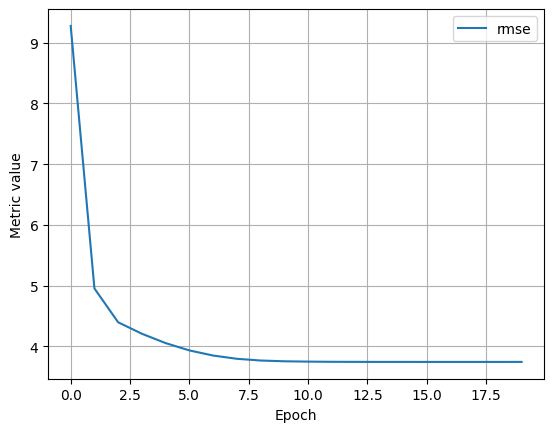

In [14]:
#Train The Model
#  Experiment 1:Training with one Feature

# The following variables are the hyperparameters.
settings_1 = ml_edu.experiment.ExperimentSettings(
    learning_rate = 0.001,
    number_epochs = 20,
    batch_size = 50,
    input_features = ['TRIP_MILES']
)

metrics = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_1 = create_model(settings_1, metrics)

experiment_1 = train_model('one_feature', model_1, training_df, 'FARE', settings_1)

ml_edu.results.plot_experiment_metrics(experiment_1, ['rmse'])
ml_edu.results.plot_model_predictions(experiment_1, training_df, 'FARE')

In [ ]:
#Experiment with hyperparameters
#It is common with machine learning to run multiple experiments to find the best set of hyperparmeters to train your model. In this step, try varying the hyperparameters one by one with this set of experiments:

#Experiment 2a: Increase the learning rate to 1.0 (batch size at 50).
#Experiment 2b: Decrease the learning rate to 0.0001 (batch size at 50).
#Experiment 2c: Increase the batch size to 500 (learning rate at 0.001).

Epoch 1/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 67.0386 - rmse: 7.7439
Epoch 2/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 45.9315 - rmse: 6.7577
Epoch 3/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 47.7721 - rmse: 6.9082
Epoch 4/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 49.9663 - rmse: 7.0538
Epoch 5/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 47.5883 - rmse: 6.8944
Epoch 6/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 45.2599 - rmse: 6.7067
Epoch 7/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 50.9898 - rmse: 7.1058
Epoch 8/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 45.5751 - rmse: 6.7377
Epoch 9/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 52.1433 - rmse: 7.2040
Epoch 10/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 49.4152 - rmse: 7.0207
Epoch 11/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 47.7792 - rmse: 6.9015
Epoch 12/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 51.3869 - rmse: 7.1539
E

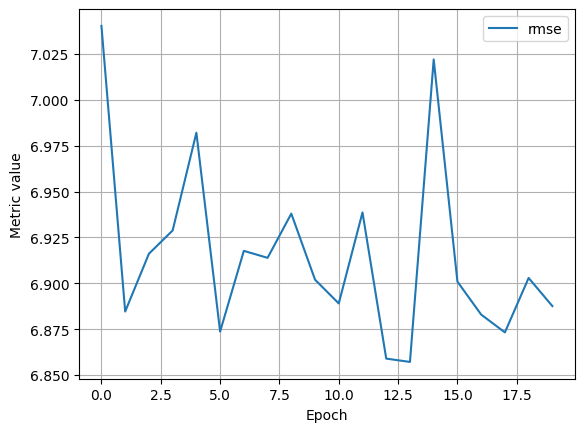

In [15]:
#@title Code - Experiment 2a

# The following variables are the hyperparameters.
# TODO - Adjust these hyperparameters to see how they impact a training run.
settings_2 = ml_edu.experiment.ExperimentSettings(
    learning_rate = 1.0,
    number_epochs = 20,
    batch_size = 50,
    input_features = ['TRIP_MILES']
)

metrics = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_2 = create_model(settings_2, metrics)

experiment_2 = train_model('one_feature_hyper', model_2, training_df, 'FARE', settings_2)

ml_edu.results.plot_experiment_metrics(experiment_2, ['rmse'])
ml_edu.results.plot_model_predictions(experiment_2, training_df, 'FARE')

Epoch 1/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 371.0616 - rmse: 19.2622
Epoch 2/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 339.3938 - rmse: 18.4224
Epoch 3/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 313.0875 - rmse: 17.6942
Epoch 4/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - loss: 288.3804 - rmse: 16.9816
Epoch 5/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 267.3977 - rmse: 16.3510
Epoch 6/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 245.4758 - rmse: 15.6670
Epoch 7/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 225.8275 - rmse: 15.0262
Epoch 8/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 201.7724 - rmse: 14.2042
Epoch 9/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 183.6734 - rmse: 13.5521
Epoch 10/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 162.8252 - rmse: 12.7599
Epoch 11/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 147.0067 - rmse: 12.1243
Epoch 12/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 

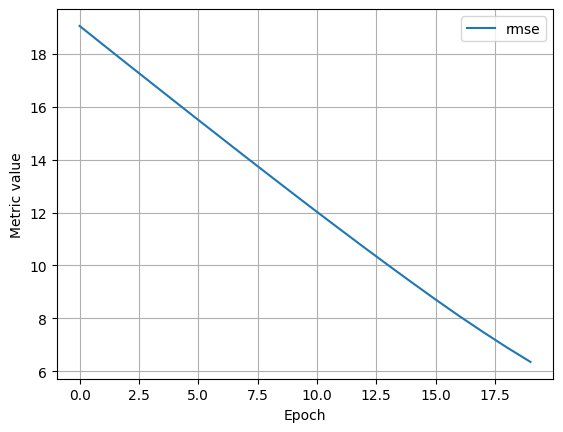

In [ ]:
#@title Code - Experiment 2b

# The following variables are the hyperparameters.
# TODO - Adjust these hyperparameters to see how they impact a training run.
settings_2 = ml_edu.experiment.ExperimentSettings(
    learning_rate = 0.0001,
    number_epochs = 20,
    batch_size = 50,
    input_features = ['TRIP_MILES']
)

metrics = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_2 = create_model(settings_2, metrics)

experiment_2 = train_model('one_feature_hyper', model_2, training_df, 'FARE', settings_2)

ml_edu.results.plot_experiment_metrics(experiment_2, ['rmse'])
ml_edu.results.plot_model_predictions(experiment_2, training_df, 'FARE')

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 708.0027 - rmse: 26.6070
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 664.2784 - rmse: 25.7729
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 631.6708 - rmse: 25.1321
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 586.0345 - rmse: 24.2077
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 551.3829 - rmse: 23.4812
Epoch 6/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 519.8061 - rmse: 22.7989
Epoch 7/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 488.1854 - rmse: 22.0938
Epoch 8/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 448.8524 - rmse: 21.1859
Epoch 9/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 424.5045 - rmse: 20.6032
Epoch 10/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 393.7684 - rmse: 19.8427
Epoch 11/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 366.1216 - rmse: 19.1336
Epoch 12/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 335.6416 - rmse: 18.3202
E

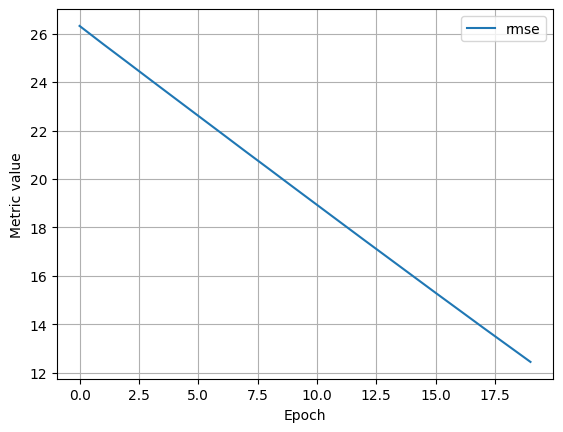

In [14]:
#@title Code - Experiment 2c

# The following variables are the hyperparameters.
# TODO - Adjust these hyperparameters to see how they impact a training run.
settings_2 = ml_edu.experiment.ExperimentSettings(
    learning_rate = 0.001,
    number_epochs = 20,
    batch_size = 500,
    input_features = ['TRIP_MILES']
)

metrics = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_2 = create_model(settings_2, metrics)

experiment_2 = train_model('one_feature_hyper', model_2, training_df, 'FARE', settings_2)

ml_edu.results.plot_experiment_metrics(experiment_2, ['rmse'])
ml_edu.results.plot_model_predictions(experiment_2, training_df, 'FARE')

Epoch 1/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 2111.8936 - rmse: 45.8410
Epoch 2/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 539.3083 - rmse: 23.0428
Epoch 3/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 35.3481 - rmse: 5.9161
Epoch 4/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 18.0392 - rmse: 4.2446
Epoch 5/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 13.8864 - rmse: 3.7203
Epoch 6/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 12.5149 - rmse: 3.5328
Epoch 7/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 12.5109 - rmse: 3.5335
Epoch 8/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 13.4402 - rmse: 3.6610
Epoch 9/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 12.5241 - rmse: 3.5362
Epoch 10/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 11.3822 - rmse: 3.3636
Epoch 11/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 11.8702 - rmse: 3.4349
Epoch 12/20
634/634 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 12.4024 - rmse: 3.

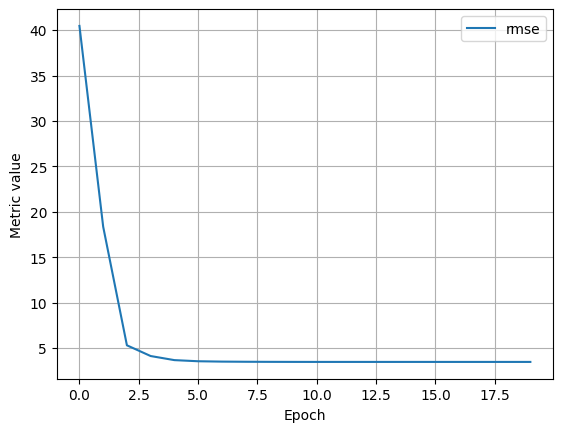

In [16]:
#Train Model with Two features
settings_3 = ml_edu.experiment.ExperimentSettings(
    learning_rate = 0.001,
    number_epochs = 20,
    batch_size = 50,
    input_features = ['TRIP_MILES', 'TRIP_MINUTES']
)

training_df['TRIP_MINUTES'] = training_df['TRIP_SECONDS']/60

metrics = [keras.metrics.RootMeanSquaredError(name='rmse')]

model_3 = create_model(settings_3, metrics)

experiment_3 = train_model('two_features', model_3, training_df, 'FARE', settings_3)

ml_edu.results.plot_experiment_metrics(experiment_3, ['rmse'])
ml_edu.results.plot_model_predictions(experiment_3, training_df, 'FARE')

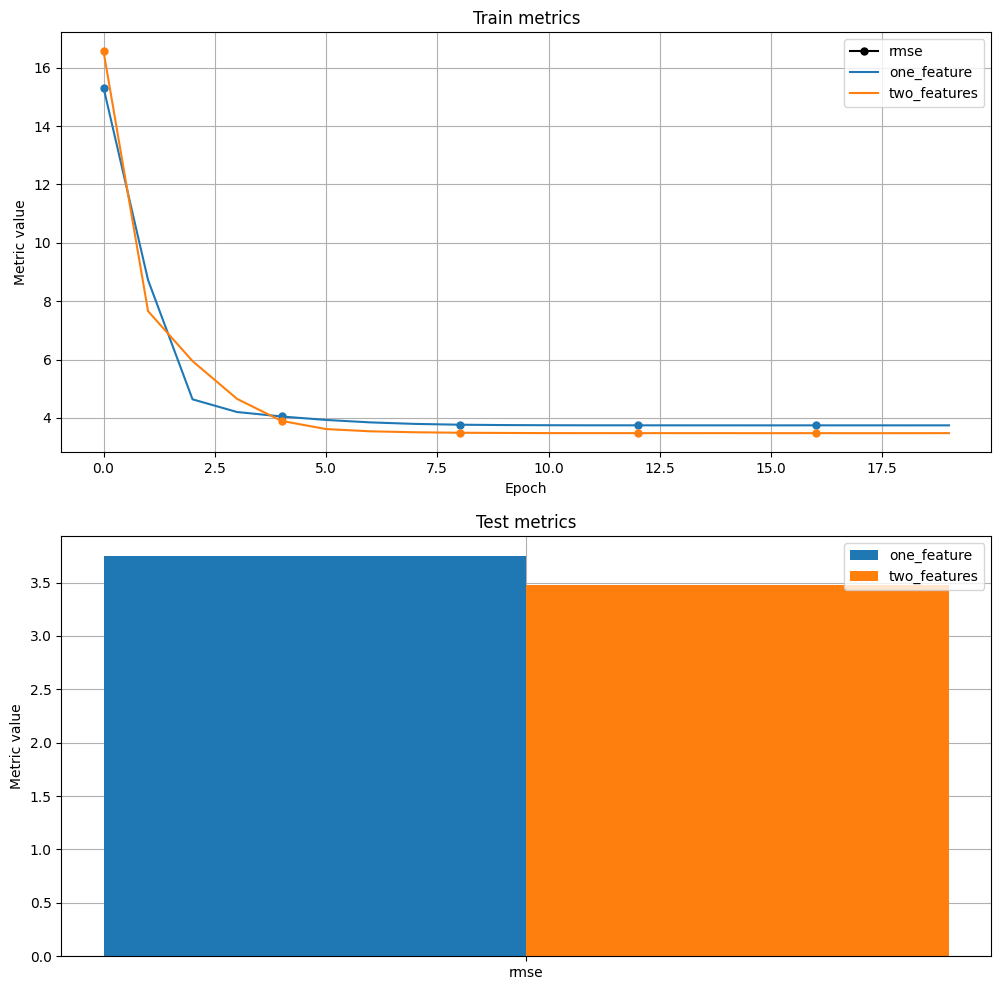

In [16]:
#Compare Experiment #1 and Experiment #3
ml_edu.results.compare_experiment([experiment_1, experiment_3], ['rmse'], training_df, training_df['FARE'].values)

In [17]:
 #  Code - Define functions to make predictions
def format_currency(x):
  return "${:.2f}".format(x)

def build_batch(df, batch_size):
  batch = df.sample(n=batch_size).copy()
  batch.set_index(np.arange(batch_size), inplace=True)
  return batch

def predict_fare(model, df, features, label, batch_size=50):
  batch = build_batch(df, batch_size)
  predicted_values = model.predict_on_batch(x={name: batch[name].values for name in features})

  data = {"PREDICTED_FARE": [], "OBSERVED_FARE": [], "L1_LOSS": [],
          features[0]: [], features[1]: []}
  for i in range(batch_size):
    predicted = predicted_values[i][0]
    observed = batch.at[i, label]
    data["PREDICTED_FARE"].append(format_currency(predicted))
    data["OBSERVED_FARE"].append(format_currency(observed))
    data["L1_LOSS"].append(format_currency(abs(observed - predicted)))
    data[features[0]].append(batch.at[i, features[0]])
    data[features[1]].append("{:.2f}".format(batch.at[i, features[1]]))

  output_df = pd.DataFrame(data)
  return output_df

def show_predictions(output):
  header = "-" * 80
  banner = header + "\n" + "|" + "PREDICTIONS".center(78) + "|" + "\n" + header
  print(banner)
  print(output)
  return

In [18]:
# Make predictions

output = predict_fare(experiment_3.model, training_df, experiment_3.settings.input_features, 'FARE')
show_predictions(output)

--------------------------------------------------------------------------------
|                                 PREDICTIONS                                  |
--------------------------------------------------------------------------------
   PREDICTED_FARE OBSERVED_FARE L1_LOSS  TRIP_MILES TRIP_MINUTES
0          $19.59        $19.00   $0.59        6.00        24.00
1          $21.38        $22.11   $0.73        7.26        18.85
2          $55.57        $61.10   $5.53       22.45        41.17
3           $9.32         $8.75   $0.57        1.90        11.00
4          $14.72        $13.77   $0.95        3.48        25.68
5          $44.83        $44.00   $0.83       17.40        38.00
6          $41.92        $40.75   $1.17       15.69        41.77
7           $8.50         $8.25   $0.25        1.44        11.73
8          $47.60        $47.25   $0.35       19.20        32.00
9          $22.72        $21.50   $1.22        7.33        26.90
10          $7.35         $7.00   $0.35   